# Advection 1D et équation de Burgers 1D

In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd().parent      # pyTQG
SRC = ROOT / "pyTQG_solver"

print(ROOT)
print(SRC)
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

C:\Users\evanl\Documents\Cours M2 POC\Stage LOPS\pyTQG
C:\Users\evanl\Documents\Cours M2 POC\Stage LOPS\pyTQG\pyTQG_solver


In [2]:
import numpy as np
import numpy.matlib
import matplotlib as mpl
import matplotlib.pyplot as plt
import scipy
import time
import hvplot.xarray
import xarray as xr
import IPython.display as ipd
import collections
import xrft

import matplotlib.colors as colors

#Modules maison
import fourier as Fourier
import chebyshev as Chebyshev
import parameters as Params
import time_scheme as TimeScheme

In [3]:
import sympy as sp
sp.init_printing(use_latex=True)

In [3]:
def loop(U0, RHS, Tmax = 2.0, dt = 0.01, scheme = 'Euler', diag = None):
    "Uniquement pour pas de temps fixes"
    N_it_max = int(np.round(Tmax/dt))
    u = np.zeros((N_it_max, U0.size))
    liste_t = np.zeros(N_it_max)
    liste_diag = np.zeros(N_it_max)
    t_ = 0.0
    u[0] = U0
    
    params = Params.Params()
    params.time_scheme = scheme
    TS = TimeScheme.TimeScheme(params, RHS, U0)
    for i in range(1, N_it_max):
        u[i, :] = TS.Step(dt)
        t_ += dt
        liste_t[i] = t_
    if diag !=None:
        for i in range(0, N_it_max) : 
            liste_diag[i] = diag(u[i, :])
        return u, liste_t, liste_diag
    return u, liste_t

In [4]:
def animate(Da, width=500, height=500,clim=None, title=None, cmap = 'seismic', logx=False, logy=False) :
    cmap='seismic'
    if clim == None : 
        clim = (float(Da.min()), float(Da.max()))
    
    anim = Da.hvplot(groupby='t',
                     title=title,
                     framewise=False,
                     width=width,
                     height=height,
                     widget_type="scrubber",
                     widget_location="bottom",
                     clim=clim,
                     cmap=cmap,
                     logx = logx,
                     logy = logy)
    return anim

## Equation d'advection 1D avec CLs périodiques
On résout l'équation 
$$
\begin{aligned}
\frac{\partial u(x, t)}{\partial t} &= c_0\frac{\partial u(x, t)}{\partial x}\\
u(x, 0) &= e^{-\frac{x^2}{2\sigma^2}}\\
x&\in[0, 2\pi]\\
u(0, t) &= u(2\pi, t)
\end{aligned}
$$

Nx = 128
dx = 0.0078125
c=100.0
dt = 7.8125e-07
CFL = 0.01
u_sum(0) = 0.24870440874886982


C:\Users\evanl\miniforge3\envs\classic_env\Lib\site-packages\matplotlib\cbook.py:1699: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
C:\Users\evanl\miniforge3\envs\classic_env\Lib\site-packages\matplotlib\cbook.py:1345: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


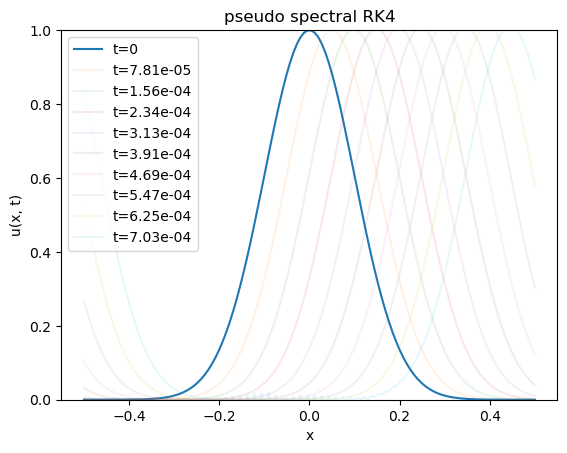

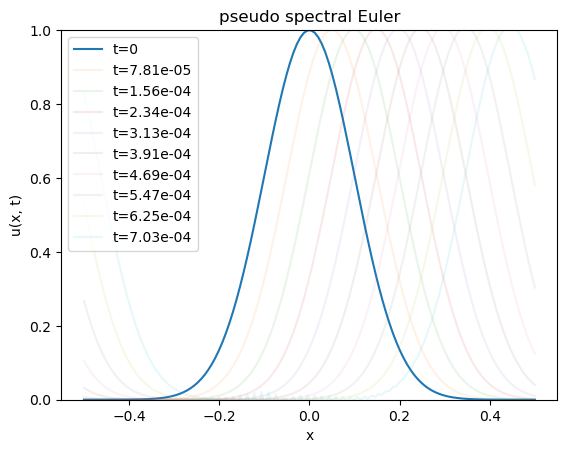

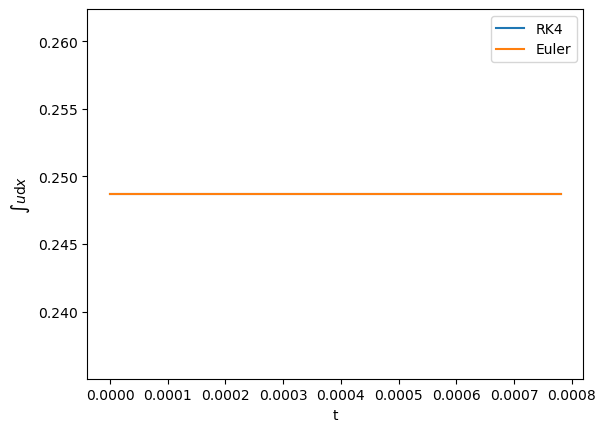

In [6]:
L = 1.0

Nx = 128

print(f"Nx = {Nx}")

x = np.linspace(-L/2., L/2., Nx, endpoint = True)

sigma = 0.1
u0 = np.exp( -x**2/(2.*sigma**2) )
u = u0.copy()

dx = L/Nx

CFL = 0.01

print(f"dx = {dx}")

c=100.0
print(f"c={c}")


dt = CFL*dx/c
#dt =1.0e-6


print(f"dt = {dt}")
print(f"CFL = {CFL}")
Nt = 1000

u_res = [u]

t=0.0
t_tot = [t]

time_scheme ='Euler'

u_int = [Fourier.Fourier_quad(u0, dx)]

def RK4(x, rhs, delta_t, *args, **kwargs):
    k1 = rhs(x, *args, **kwargs)
    k2 = rhs(x+0.5*delta_t*k1, *args, **kwargs)
    k3 = rhs(x+0.5*delta_t*k2, *args, **kwargs)
    k4 = rhs(x+delta_t*k3, *args, **kwargs)

    return x+delta_t*(k1+2.0*k2+2.0*k3+k4)/6.0

def u_tot(U):
    return np.sum(U)
def rhs_adv(x):
    return -c*Fourier.Fourier_deriv(u, a=-L/2., b=L/2., real =False)

u_int =[Fourier.Fourier_quad(u0, dx)]
print(f"u_sum(0) = {Fourier.Fourier_quad(u0, dx)}")

u_euler = u0.copy()
u_euler_t = [u_euler]
u_int_euler = [Fourier.Fourier_quad(u0, dx)]

for i in range(0, Nt):
    u_euler = u_euler - c*dt*Fourier.Fourier_deriv(u_euler, a=-L/2., b=L/2.)#intégration par méthode d'Euler
    u = RK4(u, rhs_adv, dt)
    u_res.append(u)
    u_int.append(Fourier.Fourier_quad(u.real, dx))
    u_int_euler.append(Fourier.Fourier_quad(u_euler, dx))
    u_euler_t.append(u_euler)
    t+=dt
    t_tot.append(t)


Da_1D = xr.DataArray(np.array(u_res).real, dims=['t', 'x'], coords = {'x' : x, 't':t_tot})

step_plot =100

fig = plt.figure()
plt.title("pseudo spectral RK4")
plt.plot(x, u0, label='t=0')
for i in range(1, Nt):
    if i %step_plot ==0 : 
        plt.plot(x, u_res[i], label=f't={i*dt:.2e}', alpha =0.1)
plt.xlabel("x")
plt.ylabel("u(x, t)")
plt.legend()
plt.ylim(bottom=0.0, top=1.0)

fig = plt.figure()
plt.title("pseudo spectral Euler")
plt.plot(x, u0, label='t=0')
for i in range(1, Nt):
    if i %step_plot ==0 : 
        plt.plot(x, u_euler_t[i], label=f't={i*dt:.2e}', alpha =0.1)
plt.xlabel("x")
plt.ylabel("u(x, t)")
plt.legend()
plt.ylim(bottom=0.0, top=1.0)



fig = plt.figure()
plt.plot(t_tot, u_int, label = 'RK4')
plt.plot(t_tot, u_int_euler, label='Euler')
plt.xlabel('t')
plt.ylabel(r'$\int u \mathrm{d}x$')
plt.legend()
#plt.ylim(31., 33.)

## Advection 1D avec CLs de Dirichlet
On veut résoudre l'équation suivante, sur $x\in[-\frac{\pi}{2},\frac{\pi}{2}$ : 
$$
\begin{aligned}
\frac{\partial u(x, t)}{\partial t} &= \cos(x)\frac{\partial u(x, t)}{\partial x}\\
u(-\frac{\pi}{2}, t) &= u(\frac{\pi}{2}, t)=0\\
u(x, 0) &=  \cos(x)
\end{aligned}
$$

CFL = 0.1
dx_min =0.0009462364709564153
c_max = 0.9992333045023272
dt = 9.469625028438107e-05
Nt_Euler = 6.336e+04


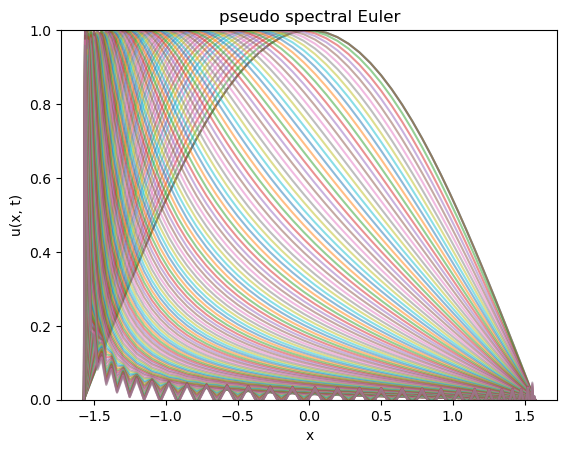

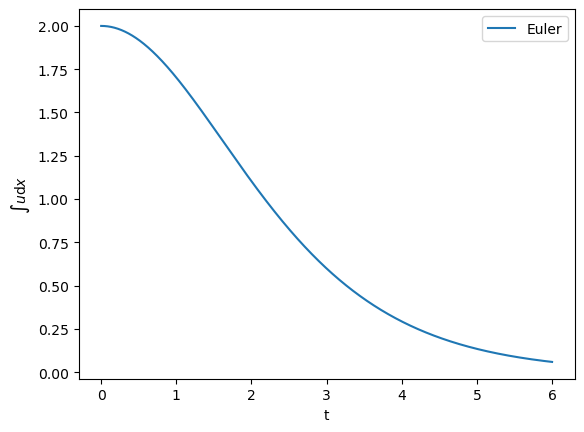

In [7]:
Nx_ = 64
X = Chebyshev.collocation_points(Nx_, a = -np.pi/2.0, b= np.pi/2.0)

u0_ = np.cos(X)

dx = (np.pi/2.0) * (np.pi/(2.0*Nx_))**2
#    (b-a)/2     * dx_min

comp_tot = lambda xx : Chebyshev.Cheb_quad(xx, a=-np.pi/2.0, b = np.pi/2.0)
c = lambda xx : np.cos(xx)
c_x = c(X)

u_ana = lambda xx, tt : np.cos(xx)*np.exp(-np.sin(xx)*tt)

rhs_adv_Cheb = lambda uu, t:c_x*Chebyshev.Cheb_FFT(uu, a = -np.pi/2.0, b=np.pi/2.0)


CFL = 0.1
c_max = np.max(c_x)
dt = CFL*dx/c_max
Tmax = 6.0


print(f"CFL = {CFL}")
print(f"dx_min ={dx}")
print(f"c_max = {c_max}")
print(f"dt = {dt}")

u_Euler, t_Euler, u_tot_Euler = loop(u0_, rhs_adv_Cheb, Tmax = Tmax, dt = dt, scheme = 'Euler', diag = comp_tot)

Nt_Euler = u_Euler.shape[0]
print(f"Nt_Euler = {Nt_Euler:.3e}")

fig = plt.figure()
plt.title("pseudo spectral Euler")
plt.plot(X, u0_, label='t=0')
step_plot = 500
for i in range(0, Nt_Euler):
    if i %step_plot ==0 : 
        plt.plot(X,u_Euler[i, :], label=f't={i*dt:.2e}', alpha =0.5)
plt.xlabel("x")
plt.ylabel("u(x, t)")
#plt.legend()
plt.ylim(bottom=0.0, top=1.0)



fig = plt.figure()

plt.plot(t_Euler, u_tot_Euler, label='Euler')
plt.xlabel('t')
plt.ylabel(r'$\int u \mathrm{d}x$')
plt.legend()



In [8]:
Da_Euler = xr.DataArray(np.array(u_Euler), dims=['t', 'x'], coords = {'x' : X, 't':t_Euler})

animate(Da_Euler)

Column
    [0] HoloViews(DynamicMap, height=500, sizing_mode='fixed', widget_location='bottom', widget_type='scrubber', width=500)
    [1] WidgetBox(align=('center', 'end'))
        [0] Player(end=63359, width=550)

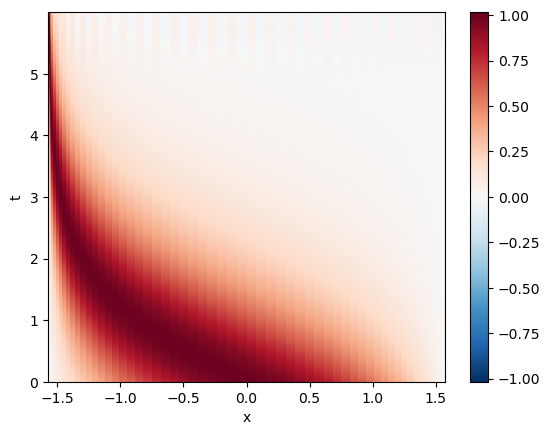

In [9]:
XX, TT = np.meshgrid(X, t_Euler, indexing = 'ij')

fig = plt.figure()
Da_Euler.plot()


Nt_RK2= 2.112e+04
CFL = 0.1
dx_min =0.0009462364709564153
c_max = 0.9992333045023272
dt = 9.469625028438107e-05


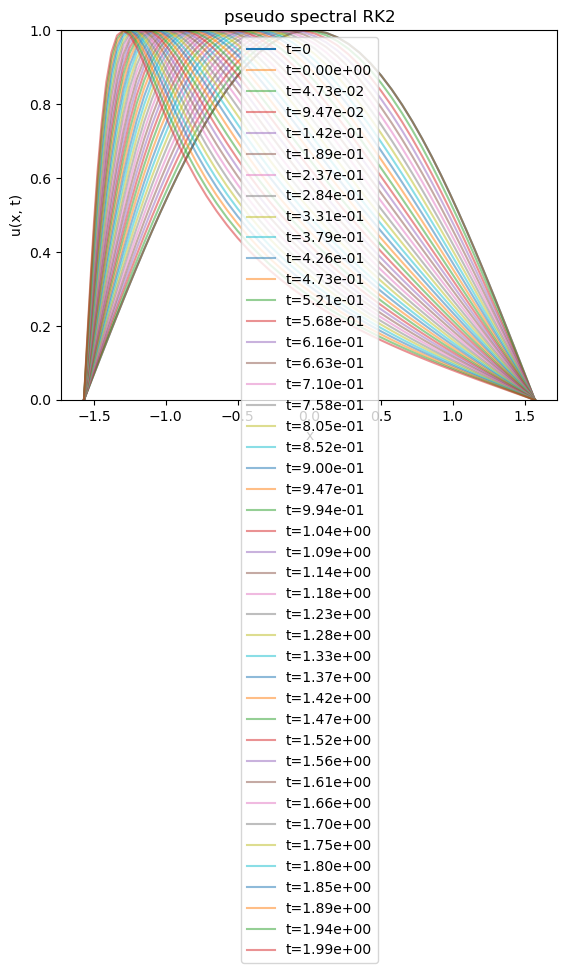

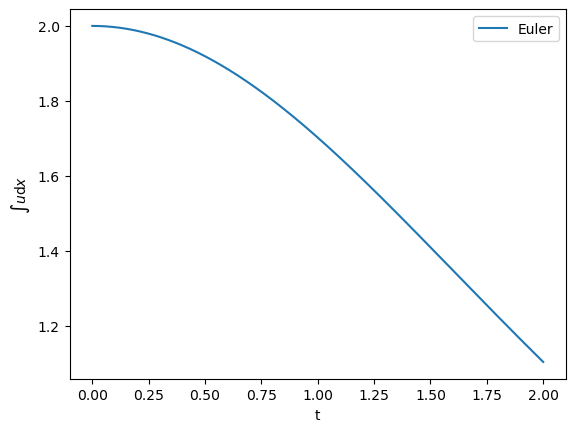

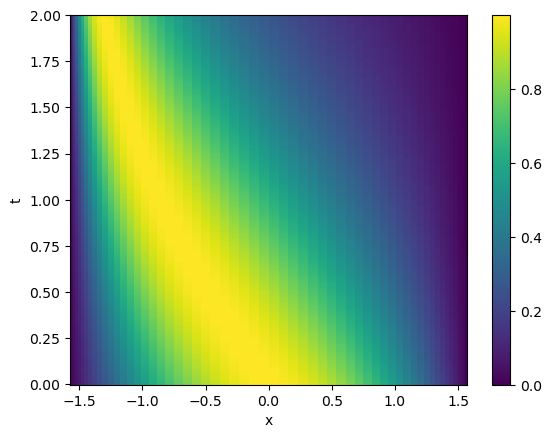

In [10]:
CFL = 0.1
c_max = np.max(c_x)
dt = CFL*dx/c_max
Tmax = 2.0


u_RK2, t_RK2, u_tot_RK2 = loop(u0_, rhs_adv_Cheb, Tmax = Tmax, dt = dt, scheme = 'RK2', diag = comp_tot)

Nt_RK2 = u_RK2.shape[0]
print(f"Nt_RK2= {Nt_RK2:.3e}")

print(f"CFL = {CFL}")
print(f"dx_min ={dx}")
print(f"c_max = {c_max}")
print(f"dt = {dt}")


fig = plt.figure()
plt.title("pseudo spectral RK2")
plt.plot(X, u0_, label='t=0')
step_plot = 500
for i in range(0, Nt_RK2):
    if i %step_plot ==0 : 
        plt.plot(X,u_RK2[i, :], label=f't={i*dt:.2e}', alpha =0.5)
plt.xlabel("x")
plt.ylabel("u(x, t)")
plt.legend()
plt.ylim(bottom=0.0, top=1.0)



fig = plt.figure()

plt.plot(t_RK2, u_tot_RK2, label='Euler')
plt.xlabel('t')
plt.ylabel(r'$\int u \mathrm{d}x$')
plt.legend()



Da_RK2 = xr.DataArray(np.array(u_RK2)[::50,:], dims=['t', 'x'], coords = {'x' : X, 't':t_RK2[::50]})
fig = plt.figure()
Da_RK2.plot()

# Considérations sur la stabilité des schémas temporels.

## Valeurs propres des matrices de différenciation de Chebyshev

N1 = 128
max(eig(D2_N1)) = 4995484.907292479
max(eig(D_N1_Dirichlet)) = 910.4348834372678
N2 = 512
max(eig(D2_N2)) = 1308895470.9364765
max(eig(D_N2)) = 14731.80020585107


Text(0, 0.5, 'Im')

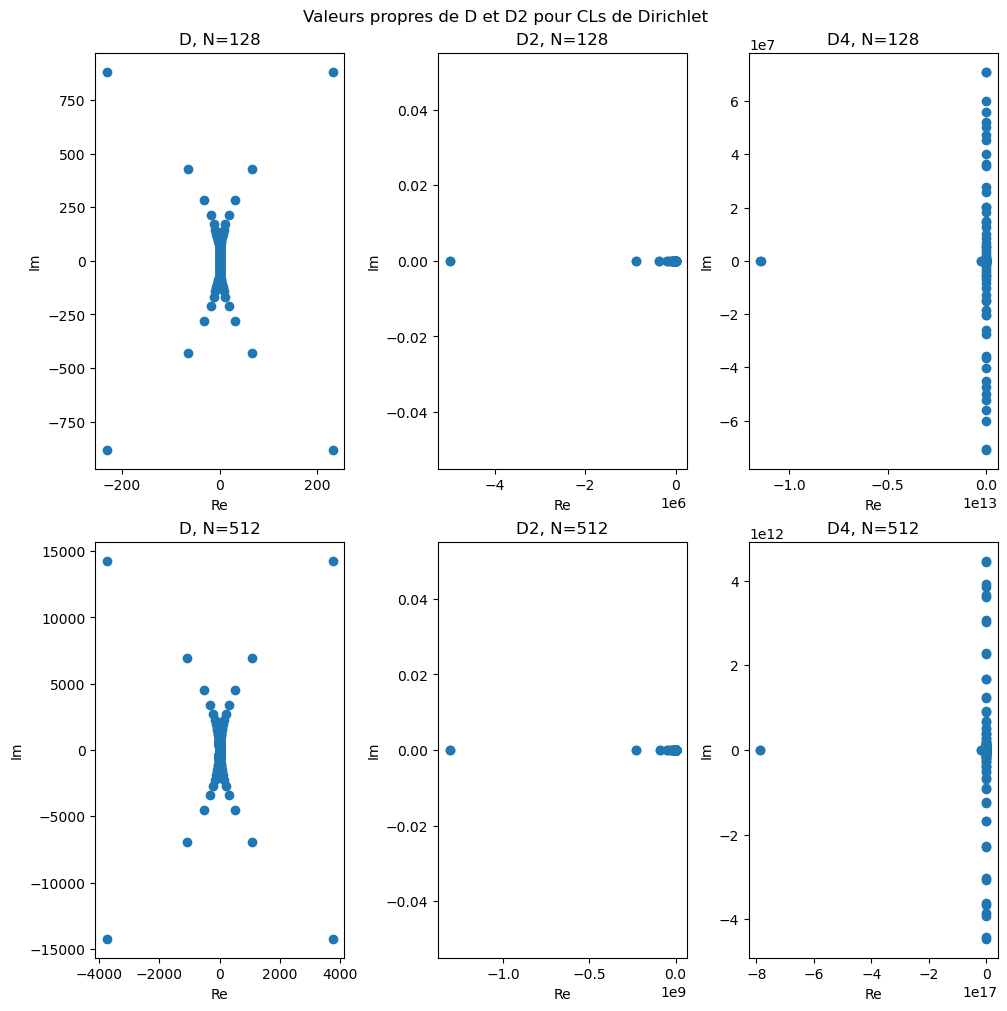

In [5]:
N1=128
N2 = 512
D_N1 = Chebyshev.Cheb_mat(N1, a= 0.0, b=np.pi)
#CL Dirichlet
D_N1_Dirichlet = Chebyshev.Cheb_mat(N1, a = 0.0, b = np.pi, Dirichlet_BC = True)
D2_N1_Dirichlet = Chebyshev.Cheb_mat(N1, a=0.0, b=np.pi, Dirichlet_BC=True, M=2)
D4_N1_Dirichlet =  Chebyshev.Cheb_mat(N1, a=0.0, b=np.pi, M=4, Dirichlet_BC=True)


eigs_D4_N1 = scipy.linalg.eigvals(D4_N1_Dirichlet)
eigs_D2_N1 = scipy.linalg.eigvals(D2_N1_Dirichlet)
eigs_D_N1 = scipy.linalg.eigvals(D_N1_Dirichlet)

D_N2 = Chebyshev.Cheb_mat(N2, a= 0.0, b=np.pi)

D_N2_Dirichlet = Chebyshev.Cheb_mat(N2, a = 0.0, b = np.pi, Dirichlet_BC = True)
D2_N2_Dirichlet = Chebyshev.Cheb_mat(N2, a=0.0, b=np.pi, Dirichlet_BC=True, M=2)
D4_N2_Dirichlet = Chebyshev.Cheb_mat(N2, a=0.0, b=np.pi, M=4, Dirichlet_BC=True)
eigs_D2_N2 = scipy.linalg.eigvals(D2_N2_Dirichlet)
eigs_D_N2 = scipy.linalg.eigvals(D_N2_Dirichlet)
eigs_D4_N2 = scipy.linalg.eigvals(D4_N2_Dirichlet)

print(f"N1 = {N1}")
print(f"max(eig(D2_N1)) = {np.max(np.abs(eigs_D2_N1))}") 
print(f"max(eig(D_N1_Dirichlet)) = {np.max(np.abs(eigs_D_N1))}") 

print(f"N2 = {N2}")
print(f"max(eig(D2_N2)) = {np.max(np.abs(eigs_D2_N2))}") 
print(f"max(eig(D_N2)) = {np.max(np.abs(eigs_D_N2))}") 

fig = plt.figure( figsize  = (10, 10), constrained_layout = True)
axs = fig.subplots(2, 3, squeeze = False, sharex = False, sharey = False)
fig.suptitle("Valeurs propres de D et D2 pour CLs de Dirichlet")


axs[0, 0].set_title(f"D, N={N1}")
axs[0, 0].scatter(eigs_D_N1.real, eigs_D_N1.imag)
axs[0, 0].set_xlabel(r"Re")
axs[0, 0].set_ylabel(r"Im")

axs[0, 1].set_title(f"D2, N={N1}")
axs[0, 1].scatter(eigs_D2_N1.real, eigs_D2_N1.imag)
axs[0, 1].set_xlabel(r"Re")
axs[0, 1].set_ylabel(r"Im")

axs[0, 2].set_title(f"D4, N={N1}")
axs[0, 2].scatter(eigs_D4_N1.real, eigs_D4_N1.imag)
axs[0, 2].set_xlabel(r"Re")
axs[0, 2].set_ylabel(r"Im")



axs[1, 0].set_title(f"D, N={N2}")
axs[1, 0].scatter(eigs_D_N2.real, eigs_D_N2.imag)
axs[1, 0].set_xlabel(r"Re")
axs[1, 0].set_ylabel(r"Im")


axs[1, 1].set_title(f"D2, N={N2}")
axs[1, 1].scatter(eigs_D2_N2.real, eigs_D2_N2.imag)
axs[1, 1].set_xlabel(r"Re")
axs[1, 1].set_ylabel(r"Im")

axs[1, 2].set_title(f"D4, N={N2}")
axs[1, 2].scatter(eigs_D4_N2.real, eigs_D4_N2.imag)
axs[1, 2].set_xlabel(r"Re")
axs[1, 2].set_ylabel(r"Im")

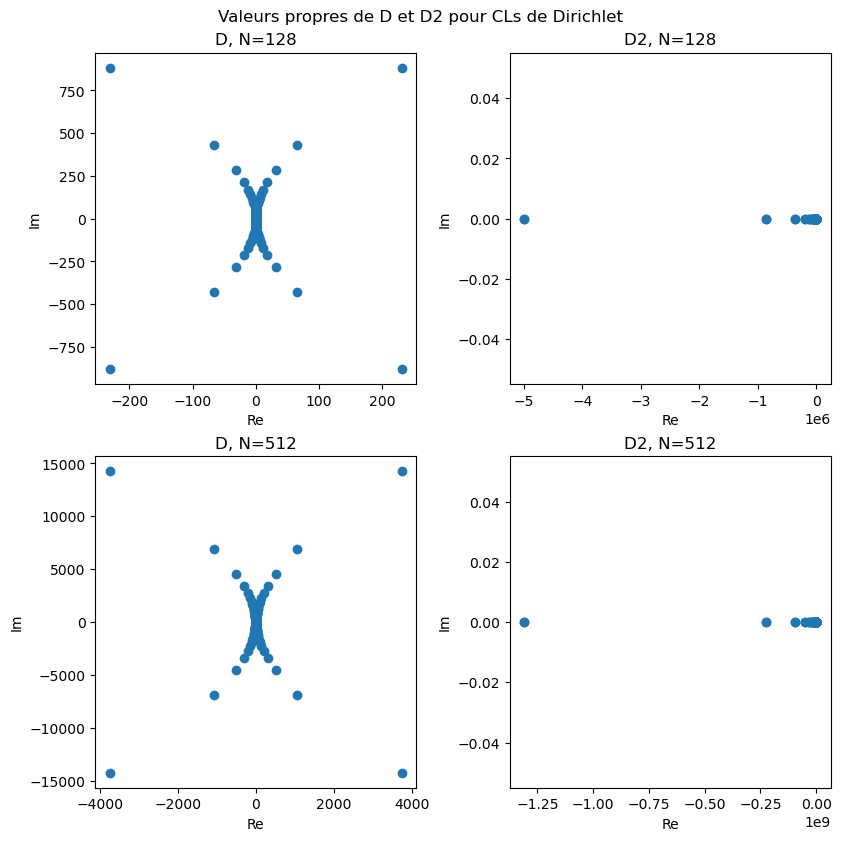

In [16]:
fig = plt.figure( figsize  = (8.3, 8.3), constrained_layout = True)
axs = fig.subplots(2, 2, squeeze = False, sharex = False, sharey = False)
fig.suptitle("Valeurs propres de D et D2 pour CLs de Dirichlet")


axs[0, 0].set_title(f"D, N={N1}")
axs[0, 0].scatter(eigs_D_N1.real, eigs_D_N1.imag)
axs[0, 0].set_xlabel(r"Re")
axs[0, 0].set_ylabel(r"Im")

axs[0, 1].set_title(f"D2, N={N1}")
axs[0, 1].scatter(eigs_D2_N1.real, eigs_D2_N1.imag)
axs[0, 1].set_xlabel(r"Re")
axs[0, 1].set_ylabel(r"Im")

axs[1, 0].set_title(f"D, N={N2}")
axs[1, 0].scatter(eigs_D_N2.real, eigs_D_N2.imag)
axs[1, 0].set_xlabel(r"Re")
axs[1, 0].set_ylabel(r"Im")


axs[1, 1].set_title(f"D2, N={N2}")
axs[1, 1].scatter(eigs_D2_N2.real, eigs_D2_N2.imag)
axs[1, 1].set_xlabel(r"Re")
axs[1, 1].set_ylabel(r"Im")

plt.savefig(r"C:\\Users\\evanl\\Documents\\Cours M2 POC\\Stage LOPS\\Rapport_stage_M2_POC\\Figures\\VP_D.png")

## Tracé diagrammes de stabilité des schémas temporels

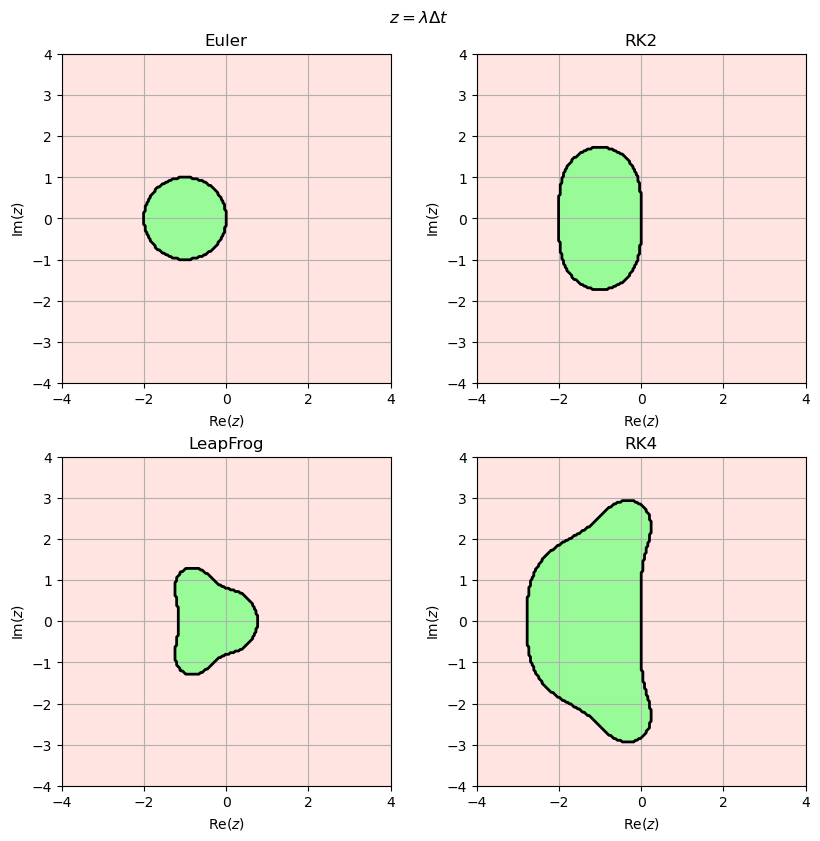

In [6]:
#Euler
z = np.exp(1.j*np.pi*np.linspace(0.0, 200.0, 1000)/100.0)



Re = np.linspace(-2.0, 2.0, 2000)
Im = np.linspace(-2.0, 2.0, 2000)

RR, II = np.meshgrid(Re, Im)
z=RR+1.0j*II


stab_Euler = lambda zz : np.abs(1.0+zz) <= 1.0
z_Euler = z[stab_Euler(z)]

pol_RK2 = lambda zz : np.abs(1.0+zz+(zz**2)/2.0)-1.0
stab_RK2 = lambda zz : pol_RK2(zz) <=0.0

pol_RK4 = lambda zz : np.abs(1.0 + zz + 0.5*zz**2 + (zz**3)/6.0 + (zz**4)/24.0)
stab_RK4 = lambda zz : pol_RK4(zz) <=1.0


def stab_LF(zz, first_step = 'Euler'):
    "cf. Shampine2009"
    zeta1 = zz+np.sqrt(1.0+zz**2)
    zeta2 = zz-np.sqrt(1.0+zz**2)
    if first_step == 'Euler':
        coeff_2 = (1.0+zz)
    elif first_step == 'RK2':
        coeff_2 = 1.0+zz+(zz**2)/2.0
    elif first_step == 'RK4':
        coeff_2 = 1.0 + zz + 0.5*zz**2 + (zz**3)/6.0 + (zz**4)/24.0
    else :
        raise ValueError(f"first_step must be in ['Euler', 'RK2', 'RK4']")
    pol_stab = zeta1+coeff_2*zeta2
    return np.abs(pol_stab) <= 1.0
    
def stability_diagram(stab_func, ax=None, Re_inf=-4.0, Re_sup=4.0, Im_inf = -4.0, Im_sup=4.0, N=200, title = None, **kwargs):
    Re = np.linspace(Re_inf, Re_sup, N)
    Im = np.linspace(Im_inf, Im_sup, N)
    RR, II = np.meshgrid(Re, Im)
    z=RR+1.0j*II
    z_stab = stab_func(z,**kwargs)
    #print(z[z_stab])
    if ax is None:
        ax = plt.axes()
    ax.set_facecolor('mistyrose')
    ax.contourf(RR, II, z_stab, levels = [0.5, 1.5], colors = 'palegreen')
    ax.contour(RR, II, z_stab,
               levels=[0.5],
               colors="black",
               linewidths=2)
    ax.set_aspect("equal")
    ax.set_xlabel(r"$\operatorname{Re}(z)$")
    ax.set_ylabel(r"$\operatorname{Im}(z)$")
    ax.grid(True)
    if title is not None:
        ax.set_title(title)
    return ax



fig = plt.figure( figsize  = (8.3, 8.3), constrained_layout = True)
axs = fig.subplots(2, 2, squeeze = False, sharex = False, sharey = False)
fig.suptitle(r"$z = \lambda \Delta t$")

ax_Euler = stability_diagram(stab_Euler, ax = axs[0, 0], title = 'Euler')
ax_RK2 = stability_diagram(stab_RK2, ax=axs[0, 1], title = 'RK2')
ax_RK4 = stability_diagram(stab_RK4, ax=axs[1, 1], title = 'RK4')
ax_LF = stability_diagram(stab_LF, axs[1, 0], title = 'LeapFrog', first_step = 'RK2')
#plt.savefig(r"C:\\Users\\evanl\\Documents\\Cours M2 POC\\Stage LOPS\\Rapport_stage_M2_POC\\Figures\\Stab_diag_TS.png")

## Mise au point d'un algorithme pour mettre les valeurs propres dans la zone de stabilité

In [13]:
def contour_stab(stab_func, N_x = 2000, N_y=2000, real_interval = (-4.0, 4.0), im_interval = (-4.0, 4.0)):
    "retourne les coordonnées (dans plan complexe) du contour de la zone de stabilité"
    if len(real_interval) != 2:
        raise ValueError("real_interval must be a 2 items list")
    if len(im_interval) != 2:
        raise ValueError("im_interval must be a 2 items list")

    if real_interval[0] >= real_interval[1]:
        raise ValueError(f"real_interval values must be passed in ascending order")
    if im_interval[0] >= im_interval[1]:
        raise ValueError(f"im_interval values must be passed in ascending order")


    Re = np.linspace(real_interval[0], im_interval[1], N_x)
    Im = np.linspace(im_interval[0], im_interval[1], N_y)
    RR, II = np.meshgrid(Re, Im, indexing = 'ij')
    Z=RR+1.0j*II
    Z_mask = np.where(stab_func(Z), True, False)
    cpx_contour = []
    for i in range(0, Z_mask.shape[0]):
        slice_y_i = Z_mask[i, :]
        for j in range(0, Z_mask.shape[1]-1):
            if np.logical_xor(slice_y_i[j], slice_y_i[j+1]):
                cpx_contour.append(Z[i, j])
    
    cpx_contour = np.array(cpx_contour)
    contour_angle = np.angle(cpx_contour)
    contour_abs = np.abs(cpx_contour)
    #renvoie un namedtuple (dictionnaire immutable)
    StabContour = collections.namedtuple('StabContour', ['Complex', 'angle', 'abs'])
    
    idx_angles_sorted = np.argsort(contour_angle)
    StabContour.Complex = cpx_contour[idx_angles_sorted]
    StabContour.angle = contour_angle[idx_angles_sorted]
    StabContour.abs = contour_abs[idx_angles_sorted]
    return StabContour


contour_RK4 = contour_stab(stab_RK4)
contour_LF = contour_stab(stab_LF)

schéma RK4
schéma LF
d_min_RK4 = 0.8224136399063765
d_min_LF = 0.6726993468706332
abs_max_VP_corr_RK4 = 2.5099474618609525
abs_max_VP_corr_LF = 1.1048696718652204


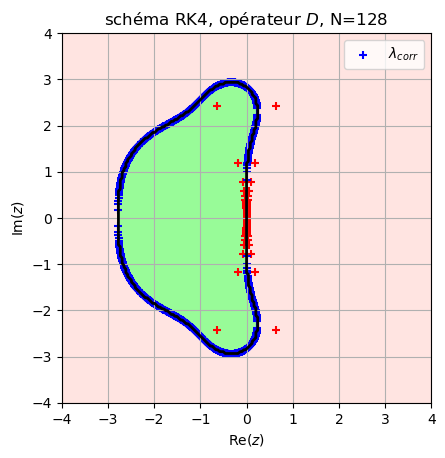

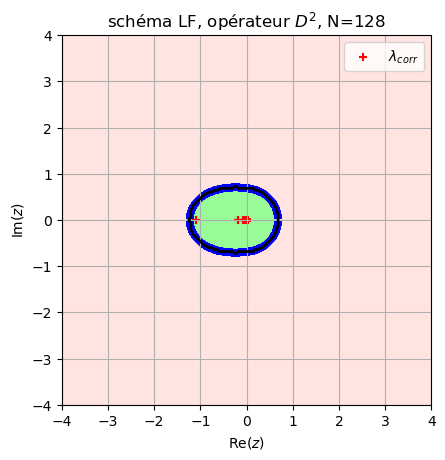

In [15]:
args_eigs_D1 = np.angle(eigs_D_N1)
dist_eigs_D1 = np.abs(eigs_D_N1)

#args_eigs_D1 = -np.pi*np.ones(eigs_D_N1.size)
#dist_eigs_D1 = np.linspace(0.0, 50.0, eigs_D_N1.size)

def corr_VP(liste_eigs, contour_stab_res, coeff_sec = 0.9, ecarts_angles_max = 0.1, get_coeff = False):
    "contour_stab_res : calculé avec fonction contour_stab, trié par arguments croissants"
    angle_eigs = np.angle(liste_eigs)
    dist_eigs = np.abs(liste_eigs)

    liste_k = np.zeros(len(liste_eigs))
    N_val_contour = contour_stab_res.angle.size
    mask_VP = np.full_like(liste_eigs, False)#False = valide, True = invalide
    for i in range(0, len(liste_eigs)):
        angle_i = angle_eigs[i]
        dist_i = dist_eigs[i]
        #print("#######################################")
        #print(f"angle_i = {angle_i}")
        
        idx_angle_sup = np.searchsorted(contour_stab_res.angle, angle_i)
        #print(f"idx_angle_sup = {idx_angle_sup}")
        real_axis = False
        if idx_angle_sup == 0:
            #angle proche de -pi
            #print(f"angle proche de -pi")
            angle_inf = contour_stab_res.angle[0]
            angle_sup = contour_stab_res.angle[-1]
            idx_inf = 0
            idx_sup = -1
            ecarts_angles = np.abs( (angle_sup - angle_inf)%(np.pi) )
            real_axis = True
        elif idx_angle_sup >= len(liste_eigs):
            #print("angle proche de pi")
            angle_inf = contour_stab_res.angle[0]
            angle_sup = contour_stab_res.angle[-1]
            idx_inf = 0
            idx_sup = -1
            ecarts_angles = np.abs( (angle_sup - angle_inf) % (np.pi))
            real_axis = True
        else :
            idx_inf = idx_angle_sup-1
            idx_sup = idx_angle_sup
            angle_inf = contour_stab_res.angle[idx_inf]
            angle_sup = contour_stab_res.angle[idx_sup]
            ecarts_angles = np.abs(angle_sup - angle_inf)
        #Cas où la VP n'est pas dans la zone de stabilité
        if (ecarts_angles > ecarts_angles_max) and (not real_axis):
            liste_k[i] = np.NaN
            mask_VP[i] = True
            continue#On passe à l'itération suivante
        #print(f"angle_sup = {angle_sup}")
        #print(f"angle_inf = {angle_inf}")
        if real_axis :
            #print(f"real_axis")
            #on se ramène dans un intervalle autour de 0
            if liste_eigs[i].real < 0.0:
                #print(f"réel négatif")
                angle_sup = angle_sup - angle_i
                angle_inf = angle_inf + angle_i
                angle_i = 0.0
            else:
                #print("réel positif")
                angle_i = 0.0
                angle_sup = angle_sup-np.pi
                angle_inf = angle_inf+np.pi
            #print(f"angle_i corrigé = {angle_i}")
            #print(f"angle_sup corrigé = {angle_sup}")
            #print(f"angle_ing corrigé = {angle_inf}")
        abs_sup = contour_stab_res.abs[idx_sup]
        abs_inf = contour_stab_res.abs[idx_inf]
        #print(f"dist_i = {dist_i}")
        #print(f"abs_sup = {abs_sup}")
        #print(f"abs_inf = {abs_inf}")
        abs_interp = np.interp(angle_i, [angle_inf, angle_sup], [abs_inf, abs_sup])
        coeff_homotethie = abs_interp/dist_i

        if coeff_homotethie >= 1.0:
            coeff_homotethie = np.NaN
        liste_k[i] = coeff_homotethie
        #print("#######################################")
    
    k_min = np.nanmin(liste_k)
    coeff_tot = coeff_sec*k_min
    ma_VP_corr = np.ma.array(coeff_tot*liste_eigs, mask = mask_VP, fill_value = 100.0)
    if get_coeff:
        return coeff_tot, ma_VP_corr
    return ma_VP_corr


def d_min_contour(eigs_corr, contour_stab_res):
    "eigs_corr : masked array (True : dans la zone de stabilité, False: en dehors)"
    angle_VP_corr = np.angle(eigs_corr)
    angle_min = angle_VP_corr.min()
    angle_max = angle_VP_corr.max()
    if angle_min <= angle_max:
        masque_cone = (contour_stab_res.angle >= angle_min) & (contour_stab_res.angle <= angle_max)
    else:
        masque_cone = (contour_stab_res.angle >= angle_min) | (contour_stab_res.angle <= angle_max)
    abs_ctr_cone = contour_stab_res.abs[masque_cone]
    if len(abs_ctr_cone) >0:
        d_min_ctr = np.min(abs_ctr_cone)
    else:
        d_min_ctr = max( np.min(contour_stab_res.abs), 1.0e-6)#gère le cas où TOUTES les VP ne peuvent pas etre dans la zone de stabilité 
    abs_VP_max = np.abs(eigs_corr).max()
    return d_min_ctr, abs_VP_max

print("schéma RK4")
VP_corr_RK4 = corr_VP(eigs_D_N1, contour_RK4)
print("schéma LF")
VP_corr_LF = corr_VP(eigs_D2_N1, contour_LF)

d_min_RK4, abs_max_VP_corr_RK4 = d_min_contour(VP_corr_RK4, contour_RK4)

d_min_LF, abs_max_VP_corr_LF = d_min_contour(VP_corr_LF, contour_LF)

#print(f"VP_corr_RK4 : {VP_corr_RK4}")
#print(f"VP_corr_LF : {VP_corr_LF}")

print(f"d_min_RK4 = {d_min_RK4}")
print(f"d_min_LF = {d_min_LF}")

print(f"abs_max_VP_corr_RK4 = {abs_max_VP_corr_RK4}")
print(f"abs_max_VP_corr_LF = {abs_max_VP_corr_LF}")

liste_angle = np.linspace(0.0, 2.0*np.pi, endpoint = False)


fig = plt.figure()
ax_RK4 = stability_diagram(stab_RK4, title = 'RK4')
ax_RK4.set_title(rf"schéma RK4, opérateur $D$, N={N1}")
ax_RK4.scatter(VP_corr_RK4.real, VP_corr_RK4.imag, marker = '+', color='r')

ax_RK4.scatter(contour_RK4.Complex.real, contour_RK4.Complex.imag, marker = '+', color = 'b', label = r'$\lambda_{corr}$')
#ax_RK4.scatter(abs_max_VP_corr_RK4*np.cos(liste_angle), abs_max_VP_corr_RK4*np.sin(liste_angle), marker='+', color = 'c', label =r"$\max{|\lambda_{corr}|}$")
#ax_RK4.scatter(d_min_RK4*np.cos(liste_angle), d_min_RK4*np.sin(liste_angle), marker='+', color = 'g', label =r"$d_{min}(S)$")
ax_RK4.legend()

fig = plt.figure()
ax_LF = stability_diagram(stab_LF, title = 'LF')
ax_LF.set_title(rf"schéma LF, opérateur $D^2$, N={N1}")
ax_LF.scatter(contour_LF.Complex.real, contour_LF.Complex.imag, marker = '+', color = 'b')
ax_LF.scatter(VP_corr_LF.real, VP_corr_LF.imag, marker = '+', color='r', label = r'$\lambda_{corr}$')
#ax_LF.scatter(abs_max_VP_corr_LF*np.cos(liste_angle), abs_max_VP_corr_LF*np.sin(liste_angle), marker='+', color = 'c', label =r"$\max{|\lambda_{corr}|}$")
#ax_LF.scatter(d_min_LF*np.cos(liste_angle), d_min_LF*np.sin(liste_angle), marker='+', color = 'g', label =r"$d_{min}(S)$")
ax_LF.legend()

### On mets tout dans une classe

In [15]:
class StabilityAnalysis:
    def __init__(self, TimeScheme):
        self.TimeScheme = TimeScheme
        self.func_stab = self.TimeScheme.func_stab
        self.contour_stab_res = contour_stab(self.func_stab)

    def Compute_stab_operators(self, liste_eigs, coeff_sec = 0.9, ecarts_angles_max = 0.1):
        if (not isinstance(liste_eigs, list)) or (not isinstance(liste_eigs, np.ndarray)) or (not isinstance(liste_eigs, tuple)):
            liste_eigs = (liste_eigs)
        ResStab = collections.namedtuple('ResStab', ['eigs', 'eigs_corr','max_abs_eigs','max_abs_eigs_corr', 'd_min_stab', 'coeff_corr'])
        liste_res = [None for i in range(0, len(liste_eigs))]
        for i in range(0, len(liste_eigs)):
            coeff_corr_i, VP_corr_i = corr_VP(liste_eigs[i], self.contour_stab_res, coeff_sec=coeff_sec, ecarts_angles_max =ecarts_angles_max, get_coeff = True)
            d_min_ctr_i, max_abs_VP_i = d_min_contour(VP_corr_i, self.contour_stab_res)
            ResStab_i = ResStab(liste_eigs[i], VP_corr_i, np.abs(liste_eigs[i]).max(), max_abs_VP_i, d_min_ctr_i, coeff_corr_i)
            liste_res[i] = ResStab_i
        if len(liste_res)==1:
            return liste_res[0]
        return tuple(liste_res)



## Burgers avec CLs périodiques et schéma RK2, avec pas de temps adaptatif

On résout l'équation 
$$
\frac{\partial u}{\partial t} + u\frac{\partial u}{\partial x} = \nu \frac{\partial^2 u}{\partial x^2}
$$

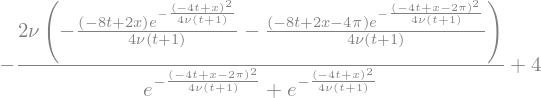

In [16]:
x, nu, t, u_ana = sp.symbols('x nu t u_{ana}')
phi = (sp.exp(-(x - 4 * t)**2 / (4 * nu * (t + 1))) +
       sp.exp(-(x - 4 * t - 2 * sp.pi)**2 / (4 * nu * (t + 1))))

u_ana = -2*nu*phi.diff(x)/phi+4
ipd.display(u_ana)
func_u_ana = sp.utilities.lambdify((x, t, nu), u_ana)

<xarray.Dataset> Size: 2MB
Dimensions:  (t: 2258, x: 128)
Coordinates:
  * t        (t) float64 18kB 0.0 0.00443 0.00886 0.01329 ... 9.99 9.994 9.999
  * x        (x) float64 1kB 0.0 0.04909 0.09817 0.1473 ... 6.136 6.185 6.234
Data variables:
    u        (t, x) float64 2MB ...
    ke       (t) float64 18kB ...
    dt       (t) float64 18kB ...
Attributes:
    Number of points:  128
    viscosity:         0.01

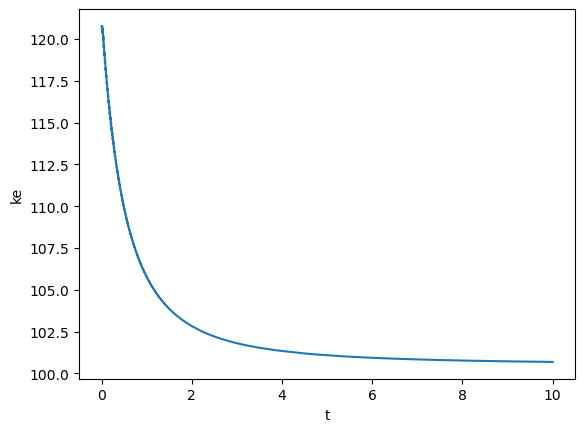

In [17]:
Ds_exp_Fourier = xr.open_dataset("Burgers_Fourier.nc")
ipd.display(Ds_exp_Fourier)

fig = plt.figure()
Ds_exp_Fourier['ke'].plot()

In [18]:
animate(Ds_exp_Fourier['u'])

Column
    [0] HoloViews(DynamicMap, height=500, sizing_mode='fixed', widget_location='bottom', widget_type='scrubber', width=500)
    [1] WidgetBox(align=('center', 'end'))
        [0] Player(end=2257, width=550)

### Résolution de manière plus "classique" (et pour un temps d'exécution moindre !)

In [4]:
x, nu, t, u_ana = sp.symbols('x nu t u_{ana}')
phi = (sp.exp(-(x - 4 * t)**2 / (4 * nu * (t + 1))) +
       sp.exp(-(x - 4 * t - 2 * sp.pi)**2 / (4 * nu * (t + 1))))

u_ana = -2*nu*phi.diff(x)/phi+4
func_u_ana = sp.utilities.lambdify((x, t, nu), u_ana)

eq_u_ana = sp.Eq(sp.S(u_ana), u_ana)

ipd.display(ipd.Math('u_{ana}='+sp.latex(u_ana)))

import Bu_Fourier_CFL as Bu_Fourier

<IPython.core.display.Math object>

C:\Users\evanl\Documents\Cours M2 POC\Stage LOPS\pyTQG
C:\Users\evanl\Documents\Cours M2 POC\Stage LOPS\pyTQG\pyTQG_solver


In [5]:
Sim_Bu_F = Bu_Fourier.Bu_Fourier(Nx=128)

visc_1 = 0.1
visc_2 = 0.05
u_ini_1 = func_u_ana(Sim_Bu_F.x, 0, visc_1)
u_ini_2 = func_u_ana(Sim_Bu_F.x, 0, visc_2)

In [25]:


res_visc_1 = Sim_Bu_F.Solve(u_ini_1, viscosite=visc_1, time_scheme = 'RK2')
res_visc_2 = Sim_Bu_F.Solve(u_ini_2, viscosite=visc_2)

dt_adv = 0.01050900966138994
dt_diff = 0.004895333573607469
Sauvegarde des sorties
####################################################
N_it = 2068
t= 10.003738994355789
U_max = 4.236984405340227
dt = 0.004895333573607469
Energie cinétique totale = 1.0147e+02
####################################################
####################################################
nombre d'itérations 2068


<xarray.Dataset> Size: 211kB
Dimensions:  (t: 101, x: 128, freq_x: 128)
Coordinates:
  * t        (t) float64 808B 0.0 0.1012 0.2012 0.3018 ... 9.7 9.803 9.901 10.0
  * x        (x) float64 1kB 0.0 0.04947 0.09895 0.1484 ... 6.184 6.234 6.283
  * freq_x   (freq_x) float64 1kB -10.11 -9.948 -9.791 ... 9.633 9.791 9.948
Data variables:
    u        (t, x) float64 103kB 4.0 4.049 4.099 4.148 ... 4.092 4.087 4.082
    ke       (t) float64 808B 121.4 122.2 122.7 124.5 ... 101.5 101.5 101.5
    dt       (t) float64 808B 0.004895 0.004656 0.00455 ... 0.004895 0.004895
    spec_u   (t, freq_x) float64 103kB 0.0004561 0.0004166 ... 3.343e-29
Attributes:
    Number of points:  128
    viscosity:         0.05
    CFL_adv:           0.9
    CFL_diff:          0.1
    TimeScheme:        RK2
    activate_dealias:  False
    coeff_dealias:     0.6666666666666666

In [26]:
res_visc_2_dealias = Sim_Bu_F.Solve(u_ini_1, viscosite=visc_2, activate_dealias=True)

dt_adv = 0.010506799919310784
dt_diff = 0.004895333573607469
Sauvegarde des sorties
####################################################
N_it = 2043
t= 10.001166490879752
U_max = 4.237875508511612
dt = 0.004895333573607469
Energie cinétique totale = 1.0147e+02
####################################################
####################################################
nombre d'itérations 2043


<xarray.Dataset> Size: 211kB
Dimensions:  (t: 101, x: 128, freq_x: 128)
Coordinates:
  * t        (t) float64 808B 0.0 0.1028 0.2007 0.3035 ... 9.703 9.8 9.903 10.0
  * x        (x) float64 1kB 0.0 0.04947 0.09895 0.1484 ... 6.184 6.234 6.283
  * freq_x   (freq_x) float64 1kB -10.11 -9.948 -9.791 ... 9.633 9.791 9.948
Data variables:
    u        (t, x) float64 103kB 4.0 4.049 4.099 4.148 ... 4.095 4.091 4.086
    ke       (t) float64 808B 120.8 120.0 119.6 119.4 ... 101.5 101.5 101.5
    dt       (t) float64 808B 0.004895 0.004895 0.004895 ... 0.004895 0.004895
    spec_u   (t, freq_x) float64 103kB 4.977e-06 1.604e-06 ... 3.049e-33
Attributes:
    Number of points:  128
    viscosity:         0.05
    CFL_adv:           0.9
    CFL_diff:          0.1
    TimeScheme:        RK2
    activate_dealias:  True
    coeff_dealias:     0.6666666666666666

In [28]:
animate(res_visc_1['u'])

Column
    [0] HoloViews(DynamicMap, height=500, sizing_mode='fixed', widget_location='bottom', widget_type='scrubber', width=500)
    [1] WidgetBox(align=('center', 'end'))
        [0] Player(end=100, width=550)

In [27]:
animate(res_visc_2['u'])

Column
    [0] HoloViews(DynamicMap, height=500, sizing_mode='fixed', widget_location='bottom', widget_type='scrubber', width=500)
    [1] WidgetBox(align=('center', 'end'))
        [0] Player(end=100, width=550)

In [29]:
animate(res_visc_2_dealias['u'])

Column
    [0] HoloViews(DynamicMap, height=500, sizing_mode='fixed', widget_location='bottom', widget_type='scrubber', width=500)
    [1] WidgetBox(align=('center', 'end'))
        [0] Player(end=100, width=550)

In [6]:
res_visc_2 = Sim_Bu_F.Solve(u_ini_2, viscosite=visc_2, time_scheme = 'RK4', activate_dealias = True)

dt_adv = 0.010503339381281817
dt_diff = 0.004895333573607469
Sauvegarde des sorties
####################################################
N_it = 2043
t= 10.001166490879752
U_max = 4.23927176248636
dt = 0.004895333573607469
Energie cinétique totale = 1.0147e+02
####################################################
####################################################
nombre d'itérations 2043


<xarray.Dataset> Size: 211kB
Dimensions:  (t: 101, x: 128, freq_x: 128)
Coordinates:
  * t        (t) float64 808B 0.0 0.1028 0.2007 0.3035 ... 9.703 9.8 9.903 10.0
  * x        (x) float64 1kB 0.0 0.04947 0.09895 0.1484 ... 6.184 6.234 6.283
  * freq_x   (freq_x) float64 1kB -10.11 -9.948 -9.791 ... 9.633 9.791 9.948
Data variables:
    u        (t, x) float64 103kB 4.0 4.049 4.099 4.148 ... 4.096 4.091 4.086
    ke       (t) float64 808B 121.4 120.4 120.0 119.8 ... 101.5 101.5 101.5
    dt       (t) float64 808B 0.004895 0.004895 0.004895 ... 0.004895 0.004895
    spec_u   (t, freq_x) float64 103kB 0.0004561 0.0004166 ... 5.183e-33
Attributes:
    Number of points:  128
    viscosity:         0.05
    CFL_adv:           0.9
    CFL_diff:          0.1
    TimeScheme:        RK4
    activate_dealias:  True
    coeff_dealias:     0.6666666666666666

In [10]:
animate(res_visc_2['u'])

Column
    [0] HoloViews(DynamicMap, height=500, sizing_mode='fixed', widget_location='bottom', widget_type='scrubber', width=500)
    [1] WidgetBox(align=('center', 'end'))
        [0] Player(end=100, width=550)

## Résolution de cette meme équation avec CLs de Dirichlet
$x\in[0, 1]$, $u(0, t) = u(1, t) = 0$

<xarray.Dataset> Size: 430kB
Dimensions:  (t: 409, x: 128)
Coordinates:
  * t        (t) float64 3kB 0.0 0.002491 0.004981 0.007472 ... 1.009 1.01 1.01
  * x        (x) float64 1kB 3.142 3.141 3.14 3.137 ... 0.001922 0.0004806 0.0
Data variables:
    u        (t, x) float64 419kB ...
    ke       (t) float64 3kB ...
    dt       (t) float64 3kB ...
Attributes:
    Number of grid points:  128
    viscosity:              1e-08

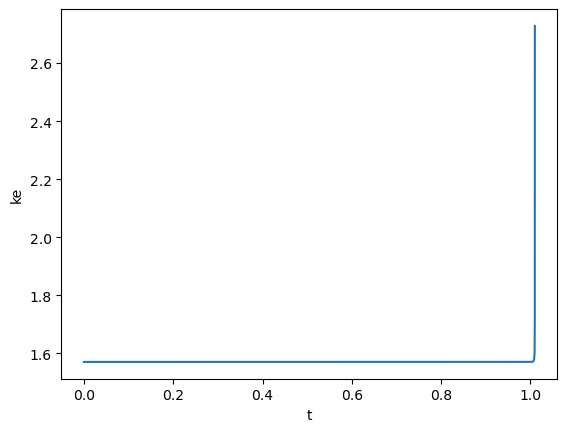

In [30]:
Ds_exp_Cheb = xr.open_dataset("Cheb_Fourier.nc")
ipd.display(Ds_exp_Cheb)

fig = plt.figure()
Ds_exp_Cheb['ke'].plot()

In [31]:
animate(Ds_exp_Cheb['u'])

Column
    [0] HoloViews(DynamicMap, height=500, sizing_mode='fixed', widget_location='bottom', widget_type='scrubber', width=500)
    [1] WidgetBox(align=('center', 'end'))
        [0] Player(end=408, width=550)

### Résolution de manière plus "classique" avec CFL

In [32]:
Ds_Cheb_CFL = xr.open_dataset("Burgers_Cheb_CFL.nc")
ipd.display(Ds_Cheb_CFL)

<xarray.Dataset> Size: 10MB
Dimensions:  (t: 10001, x: 128)
Coordinates:
  * t        (t) float64 80kB 0.0 0.0002238 0.0004477 ... 2.238 2.238 2.238
  * x        (x) float64 1kB 3.142 3.141 3.14 3.137 ... 0.001922 0.0004806 0.0
Data variables:
    u        (t, x) float64 10MB ...
    ke       (t) float64 80kB ...
    dt       (t) float64 80kB ...
Attributes:
    Number of grid points:  128
    viscosity:              0.1
    TimeScheme:             RK2
    CFL_adv:                0.9
    CFL_diff:               0.1

In [33]:
animate(Ds_Cheb_CFL['u'])

Column
    [0] HoloViews(DynamicMap, height=500, sizing_mode='fixed', widget_location='bottom', widget_type='scrubber', width=500)
    [1] WidgetBox(align=('center', 'end'))
        [0] Player(end=10000, width=550)

## Résolution par différences finies (CLs de Dirichlet) -> Cela ne diverge pas (tant que $\nu$ est pas trop petit)

In [6]:
Nx = 1024
x = np.linspace(0.0, np.pi, Nx)
dx = x[1] - x[0]

N_it_max = 100000
u_max = 50.0

visc = 0.005

Tmax = 10.0

CFL_adv = 0.9
CFL_diff = .1

u_ini = np.sin(x)

def rhs_Bu_FD(uu, t):
    u_new = uu.copy()
    u_new[0] = 0.0
    u_new[-1] = 0.0
    u_new[1:-1] = -uu[1:-1]*(uu[2:] - uu[:-2])/(2.0*dx)+visc*(uu[2:]+uu[:-2] -2.0*uu[1:-1])/(dx**2)
    return u_new

print(f"dx = {dx}")
print(f"visc = {visc}")

params = Params.Params()
params.time_scheme = 'RK2'
TS = TimeScheme.TimeScheme(params, rhs_Bu_FD, u_ini.copy())


def estimate_dt(max_U, Visc):
    dt_adv = CFL_adv*dx/max_U
    dt_visc = CFL_diff*(dx**2)/Visc
    print(f"dt_adv = {dt_adv}")
    print(f"dt_diff = {dt_visc}")
    return min(dt_adv, dt_visc)

liste_u = [u_ini]

liste_KE = [np.sum(u_ini**2)*dx]

dt = estimate_dt(np.abs(u_ini).max(), visc)
liste_dt = [dt]

t = 0.0
liste_t = [0.0]

N_it = 0


N_save_output = 100


print("debut boucle")
print(f"####################################################")
while (t <= Tmax):
    ipd.clear_output(wait = True)
    N_it +=1
    t+=dt
    u_i = TS.Step(dt)
    u_max_i = np.abs(u_i).max()
    dt = estimate_dt(u_max_i, visc)

    ke_i = np.sum(u_i**2)*dx
    if u_max_i >= u_max:
        print(f"Dépassement de valeur limite (u_max = {u_max}) en t) {t}")
        break
    if dt <= 1.0e-16:
        print(f"dt trop faible (1e-16) à t = {t}. Stop")
        break
    if (N_it % N_save_output) == 0:
        print("Sauvegarde des sorties")
        liste_dt.append(dt)
        liste_u.append(u_i)
        liste_t.append(t)
        liste_KE.append(ke_i)
    
    print("####################################################")
    print(f"N_it = {N_it}")
    print(f"t= {t}")
    print(f"U_max = {u_max_i}")
    print(f"dt = {dt}")
    print(f"Energie cinétique totale = {ke_i}")
    print("####################################################")
    
    if N_it >= N_it_max : 
        print("nombre maximum d'itérations atteint")
        break
print("####################################################")

Ds_FD = xr.Dataset(data_vars = {'u':(['t', 'x'], liste_u),
                               'ke':(['t'], liste_KE),
                               'dt':(['t'], liste_dt)}, 
                               coords = {'t':('t', liste_t), 'x':('x',x)})
Ds_FD.attrs['Number of points']= Nx
Ds_FD.attrs['viscosity'] = visc
Ds_FD.attrs['CFL_adv'] = CFL_adv
Ds_FD.attrs['CFL_diff'] = CFL_diff
ipd.display(Ds_FD)




dt_adv = 0.010079762100424411
dt_diff = 0.00018861597530673985
####################################################
N_it = 53018
t= 10.00004177880796
U_max = 0.27419937862502514
dt = 0.00018861597530673985
Energie cinétique totale = 0.08239425156364283
####################################################
####################################################


<xarray.Dataset> Size: 4MB
Dimensions:  (t: 531, x: 1024)
Coordinates:
  * t        (t) float64 4kB 0.0 0.01886 0.03772 0.05658 ... 9.959 9.978 9.997
  * x        (x) float64 8kB 0.0 0.003071 0.006142 ... 3.135 3.139 3.142
Data variables:
    u        (t, x) float64 4MB 0.0 0.003071 0.006142 ... 0.0247 1.225e-16
    ke       (t) float64 4kB 1.571 1.571 1.57 1.57 ... 0.08302 0.08273 0.08245
    dt       (t) float64 4kB 0.0001886 0.0001886 ... 0.0001886 0.0001886
Attributes:
    Number of points:  1024
    viscosity:         0.005
    CFL_adv:           0.9
    CFL_diff:          0.1

In [7]:
animate(Ds_FD['u'])

Column
    [0] HoloViews(DynamicMap, height=500, sizing_mode='fixed', widget_location='bottom', widget_type='scrubber', width=500)
    [1] WidgetBox(align=('center', 'end'))
        [0] Player(end=530, width=550)

In [ ]:
beta= 0.8
alpha = 5.0
visc = 1.0e-6

u_ana = lambda xx, tt : (2.0*visc*beta*np.pi*np.exp(-visc* tt)*np.sin(xx))/(1.0+beta*np.exp(-visc*tt)*np.cos(xx))
x = np.linspace(0.0, np.pi)

fig = plt.figure()
plt.plot(x, u_ana(x, 0.0))
plt.plot(x, u_ana(x, 100.0))
plt.xlabel('x')
plt.ylabel('y')

In [ ]:


def burgers_exact_sinus(x, t, nu, max_modes=50):
    """
    Calcule la solution analytique exacte pour u(x,0) = sin(x)
    sur x en [0, pi] avec u(0,t) = u(pi,t) = 0.0
    
    """
    z = 1.0 / (2.0 * nu)
    
    # Initialisation du numérateur et du dénominateur
    num = np.zeros_like(x)
    den = np.ones_like(x) * scipy.special.iv(0, z) # Terme n=0 du dénominateur
    
    for n in range(1, max_modes):
        I_n = scipy.special.iv(n, z)
        decay = np.exp(- (n**2) * nu * t)
        
        num += n * I_n * decay * np.sin(n * x)
        den += 2.0 * I_n * decay * np.cos(n * x)
        
    return 4.0 * nu * num / den

x = np.linspace(0.0, np.pi, 1000)
liste_t = [0.0,0.2, 0.4, 0.6, 0.8, 1.0, 2.0, 5.0, 10.0]
visc = 0.1


fig = plt.figure()
plt.title(rf"$\nu=${visc:.3e}")
for i in range(0, len(liste_t)):
    plt.plot(x,  burgers_exact_sinus(x, liste_t[i],visc, max_modes=50), label = f"t={liste_t[i]}")
plt.xlabel('x')
plt.ylabel('u(x)')
plt.legend()

In [ ]:
def burgers_exact_multimode(x, t, nu=1.0, c1=0.3, c2=0.3, c3=0.3):
    """
    Calcule la solution analytique exacte de l'équation de Burgers 
    sur [0, pi] avec conditions aux limites u(0,t) = u(pi,t) = 0.
    """
    # Calcul des atténuations temporelles exponentielles de chaque mode
    e1 = np.exp(-1 * nu * t)
    e2 = np.exp(-4 * nu * t)
    e3 = np.exp(-9 * nu * t)
    
    # Numérateur (dérivée spatiale de la fonction de la chaleur)
    num = c1 * e1 * np.sin(x) + 2 * c2 * e2 * np.sin(2*x) + 3 * c3 * e3 * np.sin(3*x)
    
    # Dénominateur (solution de l'équation de la chaleur avec Neumann homogène)
    den = 1.0 + c1 * e1 * np.cos(x) + c2 * e2 * np.cos(2*x) + c3 * e3 * np.cos(3*x)
    
    # Transformation de Cole-Hopf inverse
    u = 2 * nu * num / den
    return u

x = np.linspace(0.0, np.pi, 1000)
liste_t = [0.0,0.2, 0.4, 0.6, 0.8, 1.0, 2.0, 5.0, 10.0]
visc = 0.0


fig = plt.figure()
plt.title(rf"$\nu=${visc:.3e}")
for i in range(0, len(liste_t)):
    plt.plot(x,  burgers_exact_multimode(x, liste_t[i],nu=visc), label = f"t={liste_t[i]}")
plt.xlabel('x')
plt.ylabel('u(x)')
plt.legend()

In [ ]:

tt = 1.0+1.0/3.0
np.abs(tt%0.1)